# Chapter 6: Moduli Spaces of Stable Maps

**Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Chapter 6, printed pp. 153-200; PDF pp. 168-215. Sections 6.1-6.7 are used for coverage planning only.

**Chapter question.** Once stable maps compactify the moduli problem, when do their evaluation images behave like cycles that can be counted? Chapter 6 answers by combining simple stable maps, transversality, semipositivity, and pseudocycle theory. This notebook makes that pipeline visual: main strata and boundary strata get dimension ledgers, edge-evaluation maps are tested against the diagonal, semipositivity filters dangerous bubbles, and pseudocycle boundaries are checked for codimension at least two.

The practical lesson is that compactness alone is not enough. Counts are meaningful only when evaluation images have controlled boundary behavior. Every computation below is aimed at that question: does a boundary stratum have enough codimension to avoid changing the count?


## Source Coverage

Section 6.1 defines simple stable maps and reduces the moduli problem to simple components. Section 6.2 proves transversality for simple stable maps and uses edge evaluation maps transverse to the diagonal. Section 6.3 extends transversality to evaluation maps with marked points. Section 6.4 introduces semipositivity and explains why certain bubble strata have codimension large enough not to corrupt counts. Section 6.5 develops pseudocycles and omega-limit boundaries. Section 6.6 applies this to Gromov-Witten pseudocycles. Section 6.7 treats pseudocycles of graphs, where several components and incidence conditions are assembled simultaneously.

The source-coverage artifact records those sections and assigns each to a notebook representation: stratum codimension chart, edge-evaluation diagonal plot, semipositivity ledger, pseudocycle proof graph, graph-pseudocycle incidence diagram, and a dimension lab.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import networkx as nx
import numpy as np
import pandas as pd
import sympy as sp


def find_book_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "J-Holomorphic-Curves-and-Symplectic-Topology" / "AGENTS.md").exists():
            return candidate / "J-Holomorphic-Curves-and-Symplectic-Topology"
        if (candidate / "AGENTS.md").exists() and candidate.name == "J-Holomorphic-Curves-and-Symplectic-Topology":
            return candidate
    raise RuntimeError("Could not locate the JHCST book root")

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = "chapter-06"
ART_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ART_ROOT / "figures"
CHECK_DIR = ART_ROOT / "checks"
TABLE_DIR = ART_ROOT / "tables"
for directory in (FIG_DIR, CHECK_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)


In [2]:
source_coverage = {
    "source": "McDuff-Salamon, J-holomorphic Curves and Symplectic Topology, 2nd ed., Chapter 6",
    "source_span_used": "printed pp. 153-200; PDF pp. 168-215",
    "sections": [
        {"section": "6.1", "focus": "simple stable maps and reduction to simple components", "artifact": "stable-map-stratum-codimension.png"},
        {"section": "6.2", "focus": "transversality for simple stable maps and edge evaluation", "artifact": "edge-evaluation-diagonal-transversality.png"},
        {"section": "6.3", "focus": "evaluation map transversality with marked points", "artifact": "evaluation-constraint-lab.csv"},
        {"section": "6.4", "focus": "semipositivity and bubble-dimension exclusions", "artifact": "semipositivity-bubble-ledger.png"},
        {"section": "6.5", "focus": "pseudocycles and omega-limit boundary codimension", "artifact": "pseudocycle-proof-pipeline.png"},
        {"section": "6.6", "focus": "Gromov-Witten pseudocycle construction", "artifact": "pseudocycle-proof-pipeline.png"},
        {"section": "6.7", "focus": "pseudocycle of graphs and incidence conditions", "artifact": "graph-pseudocycle-incidence.png"},
    ],
    "copyright_boundary": "Original prose and generated finite models only; no copied source passages, exercises, screenshots, or figures.",
}
library_routing = {
    "sympy": "dimension formulas and node-subtraction identities are symbolic checks",
    "numpy": "edge-evaluation transversality and parameter labs use numerical grids",
    "matplotlib": "stratum and diagonal visuals need durable static inspection",
    "networkx": "stable-map graphs and pseudocycle proof dependencies are graph structures",
    "pandas": "codimension, semipositivity, and lab cases are auditable ledgers",
}
visual_storyboard = [
    {"visual": "stable-map-stratum-codimension.png", "concept": "main and boundary strata", "inspection_target": "boundary strata have positive codimension", "invariant": "omega-limit rows have codimension at least two"},
    {"visual": "edge-evaluation-diagonal-transversality.png", "concept": "edge evaluation transverse to diagonal", "inspection_target": "difference map crosses zero with full rank", "invariant": "Jacobian determinant is nonzero"},
    {"visual": "semipositivity-bubble-ledger.png", "concept": "semipositivity removes dangerous low-codimension bubbles", "inspection_target": "negative Chern rows are flagged as excluded", "invariant": "accepted rows do not lower boundary codimension below two"},
    {"visual": "pseudocycle-proof-pipeline.png", "concept": "from evaluation image to pseudocycle", "inspection_target": "omega-limit boundary is codimension at least two", "invariant": "proof graph reaches GW pseudocycle and graph pseudocycle"},
    {"visual": "graph-pseudocycle-incidence.png", "concept": "graph pseudocycle incidence constraints", "inspection_target": "nodes impose diagonal matching and marks impose constraints", "invariant": "node matching subtracts target dimension per edge"},
]
save_json(source_coverage, UNIT, "checks", "source-coverage.json")
save_json(library_routing, UNIT, "checks", "library-routing.json")
save_json(visual_storyboard, UNIT, "checks", "visual-storyboard.json")


WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology/artifacts/chapter-06/checks/visual-storyboard.json')

## Library Routing

This chapter mixes analysis, combinatorics, and finite-dimensional topology. SymPy checks the dimension formulas used in the ledgers. NumPy builds the edge-evaluation difference map and parameter sweeps. Matplotlib displays codimension, diagonal, and semipositivity visuals. NetworkX represents both the proof pipeline and the graph-pseudocycle domain. Pandas keeps the status of each stratum visible, especially the distinction between accepted pseudocycle boundaries and excluded dangerous bubbles.

## Visualization Storyboard

The notebook starts by comparing the main stratum with one-node, ghost, and multi-node strata. It then zooms into the key local transversality mechanism: edge evaluation crossing the diagonal. Semipositivity is presented as a filter on bubble Chern numbers and boundary codimensions. The pseudocycle proof graph shows how transversality and compactification become evaluation pseudocycles. The graph-pseudocycle diagram makes node matching and marked-point constraints visible. The applied lab varies Chern number, marks, and node count to test when a stratum still has enough codimension.


## 1. Stratum Codimensions and Semipositivity

A stable-map compactification includes boundary strata. For counts, the dangerous case is not simply that a boundary exists, but that it has too little codimension. Semipositivity is a hypothesis designed to rule out bubble strata whose Chern numbers would produce low-dimensional boundary contributions. The chart below uses a genus-zero real dimension model: a main stratum, a one-node boundary, a ghost component, and a two-node boundary. The ledger marks which rows are safe for pseudocycle counts.


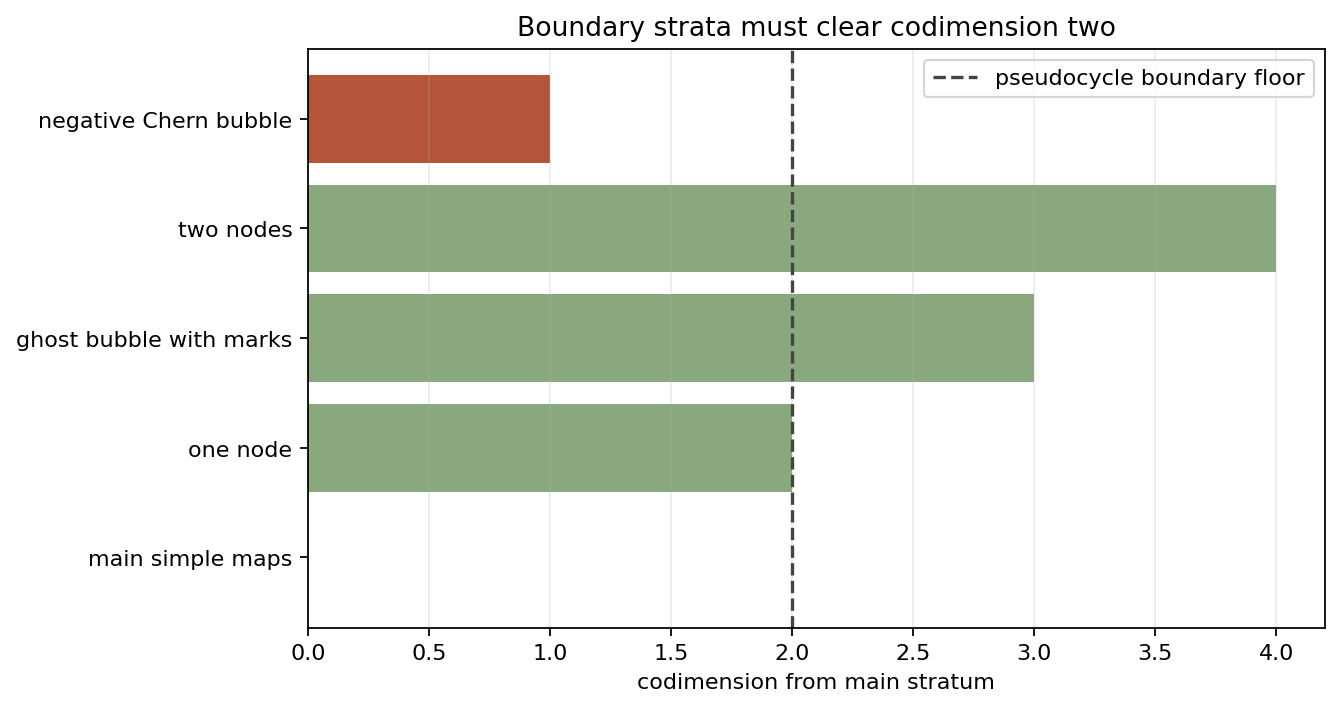

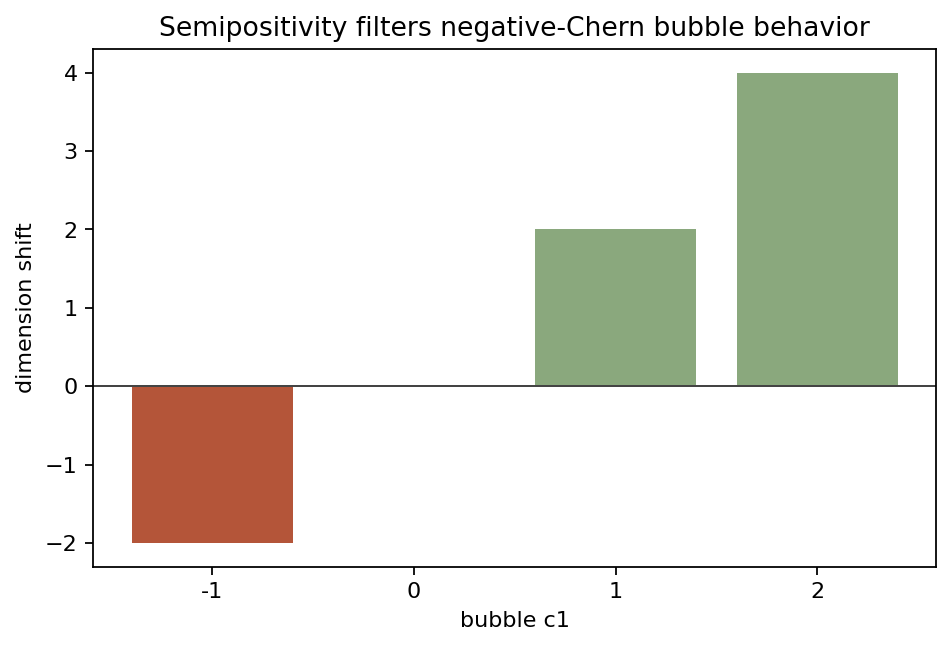

In [3]:
main_dim = 8
strata = pd.DataFrame([
    {"stratum": "main simple maps", "expected_dim": 8, "codim_from_main": 0, "role": "counting image", "safe_boundary": True},
    {"stratum": "one node", "expected_dim": 6, "codim_from_main": 2, "role": "omega-limit boundary", "safe_boundary": True},
    {"stratum": "ghost bubble with marks", "expected_dim": 5, "codim_from_main": 3, "role": "stable-domain boundary", "safe_boundary": True},
    {"stratum": "two nodes", "expected_dim": 4, "codim_from_main": 4, "role": "deeper boundary", "safe_boundary": True},
    {"stratum": "negative Chern bubble", "expected_dim": 7, "codim_from_main": 1, "role": "excluded by semipositivity", "safe_boundary": False},
])
strata.to_csv(TABLE_DIR / "stable-map-stratum-codimension.csv", index=False)
fig, ax = plt.subplots(figsize=(8.2, 4.7))
colors = ["#8aa87d" if row.safe_boundary else "#b45539" for row in strata.itertuples()]
ax.barh(strata["stratum"], strata["codim_from_main"], color=colors)
ax.axvline(2, color="#444", linestyle="--", label="pseudocycle boundary floor")
ax.set_xlabel("codimension from main stratum")
ax.set_title("Boundary strata must clear codimension two")
ax.legend()
ax.grid(axis="x", alpha=0.25)
fig_path = save_matplotlib(fig, UNIT, "figures", "stable-map-stratum-codimension.png")
plt.close(fig)

chern_rows = pd.DataFrame([
    {"bubble_c1": -1, "dimension_shift": -2, "semipositive_allowed": False, "boundary_codim_after_filter": None},
    {"bubble_c1": 0, "dimension_shift": 0, "semipositive_allowed": True, "boundary_codim_after_filter": 2},
    {"bubble_c1": 1, "dimension_shift": 2, "semipositive_allowed": True, "boundary_codim_after_filter": 2},
    {"bubble_c1": 2, "dimension_shift": 4, "semipositive_allowed": True, "boundary_codim_after_filter": 3},
])
chern_rows.to_csv(TABLE_DIR / "semipositivity-bubble-ledger.csv", index=False)
fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.bar(chern_rows["bubble_c1"].astype(str), chern_rows["dimension_shift"], color=["#b45539" if not ok else "#8aa87d" for ok in chern_rows["semipositive_allowed"]])
ax.axhline(0, color="#444", lw=0.9)
ax.set_xlabel("bubble c1")
ax.set_ylabel("dimension shift")
ax.set_title("Semipositivity filters negative-Chern bubble behavior")
semi_path = save_matplotlib(fig, UNIT, "figures", "semipositivity-bubble-ledger.png")
plt.close(fig)
stratum_checks = {
    "main_dimension": main_dim,
    "unsafe_rows_flagged": bool((~strata["safe_boundary"]).any()),
    "all_safe_boundaries_codim_at_least_two": bool((strata[strata["role"] != "counting image"].query("safe_boundary == True")["codim_from_main"] >= 2).all()),
    "negative_chern_excluded": bool((chern_rows[chern_rows["bubble_c1"] < 0]["semipositive_allowed"] == False).all()),
    "passed": True,
}
stratum_checks["passed"] = stratum_checks["all_safe_boundaries_codim_at_least_two"] and stratum_checks["negative_chern_excluded"]
save_json(stratum_checks, UNIT, "checks", "pseudocycle-codimension-checks.json")
display_artifact(fig_path, width=820)
display_artifact(semi_path, width=680)


## 2. Edge Evaluation Transverse to the Diagonal

At a node, two component evaluations must agree in the target. That is the diagonal condition in `M x M`. Transversality says the edge-evaluation map crosses this diagonal cleanly, so imposing a node subtracts the target dimension rather than creating an uncontrolled singular constraint. The finite model below plots the norm of a difference map `ev_left(s)-ev_right(t)` and checks that its Jacobian at the zero has full rank.


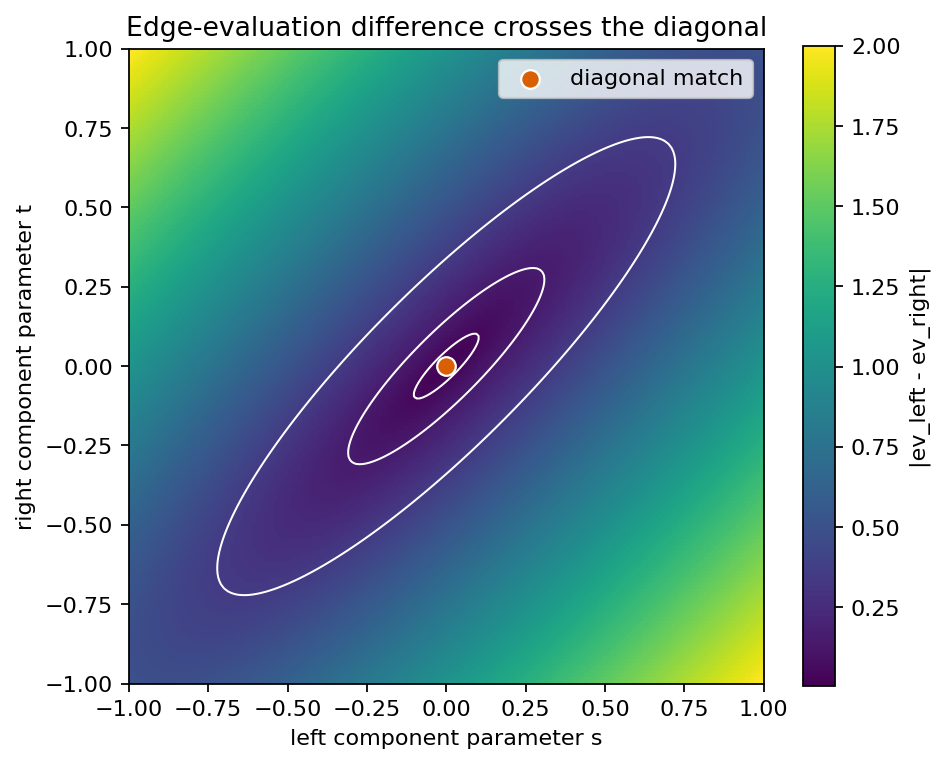

In [4]:
s = np.linspace(-1.0, 1.0, 180)
t = np.linspace(-1.0, 1.0, 180)
S, T = np.meshgrid(s, t)
Delta_x = S - T
Delta_y = 0.25 * (S + T)
Delta_norm = np.sqrt(Delta_x**2 + Delta_y**2)
fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(Delta_norm, extent=[s.min(), s.max(), t.min(), t.max()], origin="lower", cmap="viridis")
ax.contour(S, T, Delta_norm, levels=[0.05, 0.15, 0.35], colors="white", linewidths=0.9)
ax.scatter([0], [0], s=70, color="#d95f02", edgecolor="white", label="diagonal match")
ax.set_xlabel("left component parameter s")
ax.set_ylabel("right component parameter t")
ax.set_title("Edge-evaluation difference crosses the diagonal")
ax.legend()
fig.colorbar(im, ax=ax, label="|ev_left - ev_right|")
fig_path = save_matplotlib(fig, UNIT, "figures", "edge-evaluation-diagonal-transversality.png")
plt.close(fig)
J = np.array([[1.0, -1.0], [0.25, 0.25]])
determinant = float(np.linalg.det(J))
edge_checks = {"jacobian": J.tolist(), "determinant": determinant, "full_rank": bool(np.linalg.matrix_rank(J) == 2), "node_matching_subtracts_real_target_dimension": 4, "passed": bool(abs(determinant) > 1e-12)}
save_json(edge_checks, UNIT, "checks", "edge-evaluation-transversality-checks.json")
display_artifact(fig_path, width=680)


## 3. Pseudocycle Pipeline and Graph Pseudocycles

A pseudocycle is allowed to have a limiting boundary only when that boundary has codimension at least two. For Gromov-Witten theory, the evaluation map from the compactified moduli space must therefore have controlled omega-limit image. The proof graph displays the route from simple stable-map transversality to GW pseudocycles and then to graph pseudocycles. The second diagram shows a graph-pseudocycle domain where node edges impose diagonal matching and marked leaves impose incidence constraints.


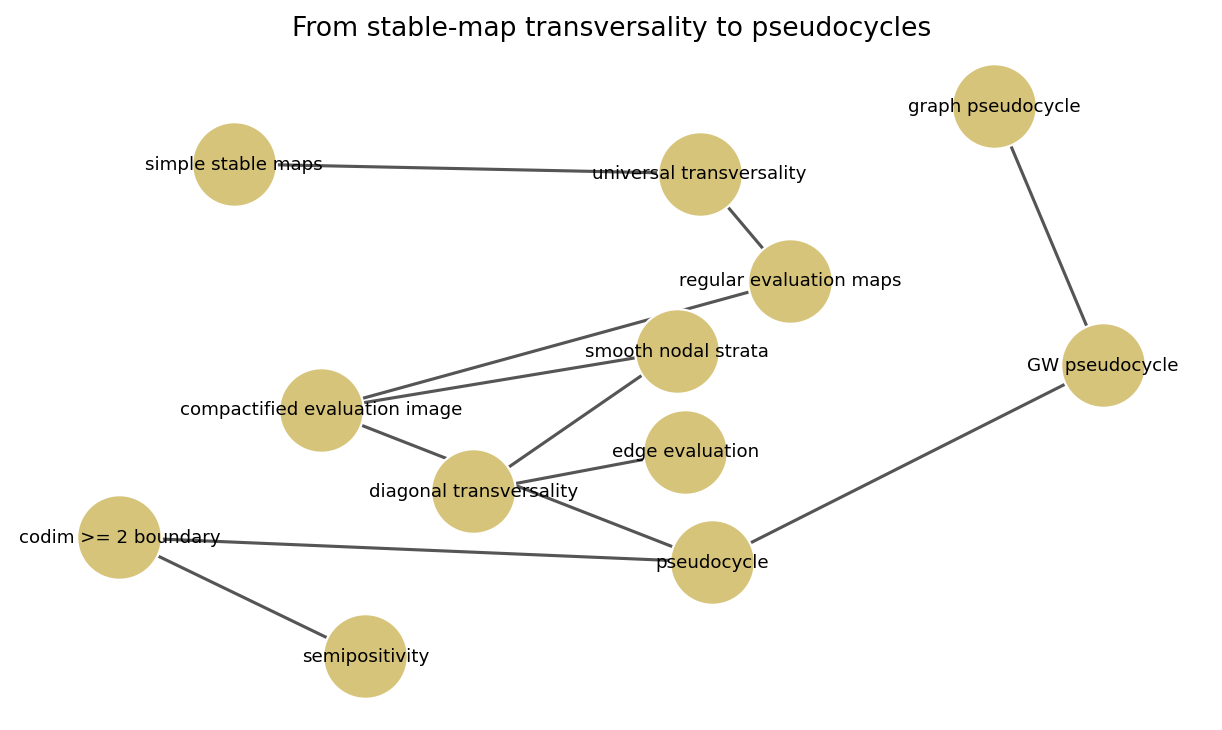

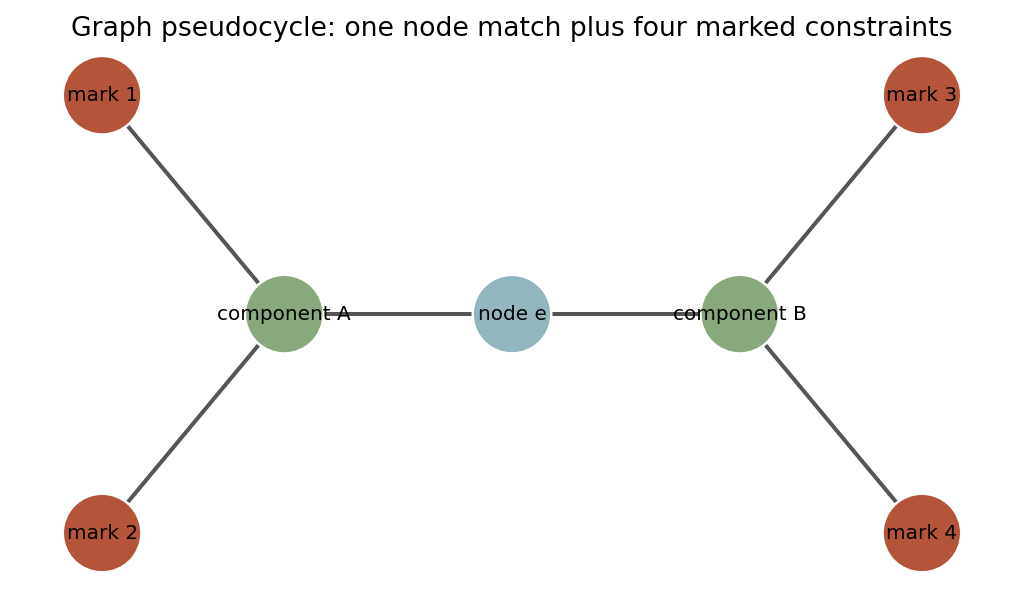

In [5]:
P = nx.DiGraph()
P.add_edges_from([
    ("simple stable maps", "universal transversality"),
    ("universal transversality", "regular evaluation maps"),
    ("edge evaluation", "diagonal transversality"),
    ("diagonal transversality", "smooth nodal strata"),
    ("semipositivity", "codim >= 2 boundary"),
    ("smooth nodal strata", "compactified evaluation image"),
    ("regular evaluation maps", "compactified evaluation image"),
    ("codim >= 2 boundary", "pseudocycle"),
    ("compactified evaluation image", "pseudocycle"),
    ("pseudocycle", "GW pseudocycle"),
    ("GW pseudocycle", "graph pseudocycle"),
])
pos = nx.spring_layout(P, seed=606, k=1.0)
fig, ax = plt.subplots(figsize=(9.6, 5.4))
nx.draw_networkx_nodes(P, pos, node_color="#d7c47b", node_size=1450, edgecolors="white", linewidths=1.0, ax=ax)
nx.draw_networkx_edges(P, pos, arrowstyle="-|>", arrowsize=14, width=1.4, edge_color="#555", ax=ax)
nx.draw_networkx_labels(P, pos, font_size=8.2, ax=ax)
ax.set_title("From stable-map transversality to pseudocycles")
ax.axis("off")
proof_path = save_matplotlib(fig, UNIT, "figures", "pseudocycle-proof-pipeline.png")
plt.close(fig)

Q = nx.Graph()
Q.add_edges_from([("component A", "node e"), ("node e", "component B"), ("component A", "mark 1"), ("component A", "mark 2"), ("component B", "mark 3"), ("component B", "mark 4")])
posQ = {"component A": (-1,0), "node e": (0,0), "component B": (1,0), "mark 1": (-1.8,0.7), "mark 2": (-1.8,-0.7), "mark 3": (1.8,0.7), "mark 4": (1.8,-0.7)}
colors = ["#8aa87d" if n.startswith("component") else "#93b5bd" if n.startswith("node") else "#b45539" for n in Q.nodes]
fig, ax = plt.subplots(figsize=(8.0, 4.3))
nx.draw_networkx_nodes(Q, posQ, node_color=colors, node_size=1250, edgecolors="white", linewidths=1.1, ax=ax)
nx.draw_networkx_edges(Q, posQ, width=1.8, edge_color="#555", ax=ax)
nx.draw_networkx_labels(Q, posQ, font_size=9, ax=ax)
ax.set_title("Graph pseudocycle: one node match plus four marked constraints")
ax.axis("off")
graph_path = save_matplotlib(fig, UNIT, "figures", "graph-pseudocycle-incidence.png")
plt.close(fig)
proof_checks = {"proof_nodes": int(P.number_of_nodes()), "reaches_gw_pseudocycle": bool(nx.has_path(P, "simple stable maps", "GW pseudocycle")), "reaches_graph_pseudocycle": bool(nx.has_path(P, "simple stable maps", "graph pseudocycle")), "graph_tree": bool(nx.is_tree(Q)), "node_edges": 1, "passed": True}
proof_checks["passed"] = proof_checks["reaches_gw_pseudocycle"] and proof_checks["reaches_graph_pseudocycle"] and proof_checks["graph_tree"]
save_json(proof_checks, UNIT, "checks", "pseudocycle-proof-pipeline-checks.json")
display_artifact(proof_path, width=940)
display_artifact(graph_path, width=800)


## 4. Dimension Formula Checks

The dimension formula is the notebook's symbolic guardrail. For genus-zero maps to a target of complex dimension `n`, a one-component real expected dimension with `k` marked points is modeled as `2n + 2c1 + 2k - 6`. A node matching condition subtracts the real target dimension `2n`. This does not replace the full theorem, but it checks the bookkeeping used in the transversality and graph-pseudocycle sections.


In [6]:
n_sym, c_sym, k_sym, e_sym = sp.symbols("n c k e", integer=True)
component_dim = 2*n_sym + 2*c_sym + 2*k_sym - 6
node_subtraction = 2*n_sym*e_sym
graph_dim = component_dim - node_subtraction
symbolic_checks = {
    "component_dimension_formula": str(component_dim),
    "node_subtraction_formula": str(node_subtraction),
    "sample_component_dim_n2_c3_k2": int(component_dim.subs({n_sym: 2, c_sym: 3, k_sym: 2})),
    "sample_one_edge_subtraction_n2": int(node_subtraction.subs({n_sym: 2, e_sym: 1})),
}
symbolic_checks["sample_after_one_node"] = symbolic_checks["sample_component_dim_n2_c3_k2"] - symbolic_checks["sample_one_edge_subtraction_n2"]
symbolic_checks["passed"] = symbolic_checks["sample_component_dim_n2_c3_k2"] == 8 and symbolic_checks["sample_after_one_node"] == 4
save_json(symbolic_checks, UNIT, "checks", "dimension-formula-checks.json")
symbolic_checks


{'component_dimension_formula': '2*c + 2*k + 2*n - 6',
 'node_subtraction_formula': '2*e*n',
 'sample_component_dim_n2_c3_k2': 8,
 'sample_one_edge_subtraction_n2': 4,
 'sample_after_one_node': 4,
 'passed': True}

## Applied Lab

The lab varies Chern number, number of marked points, and number of nodes for a target of complex dimension two. The first question is whether the stratum has enough dimension to carry the requested incidence constraints. The second question is whether adding nodes moves the row into the codimension-at-least-two boundary zone required for pseudocycles. Try reading each row as a miniature version of Sections 6.2-6.7: transversality supplies the dimension, semipositivity filters bad bubbles, and pseudocycle theory decides whether the boundary can affect counts.


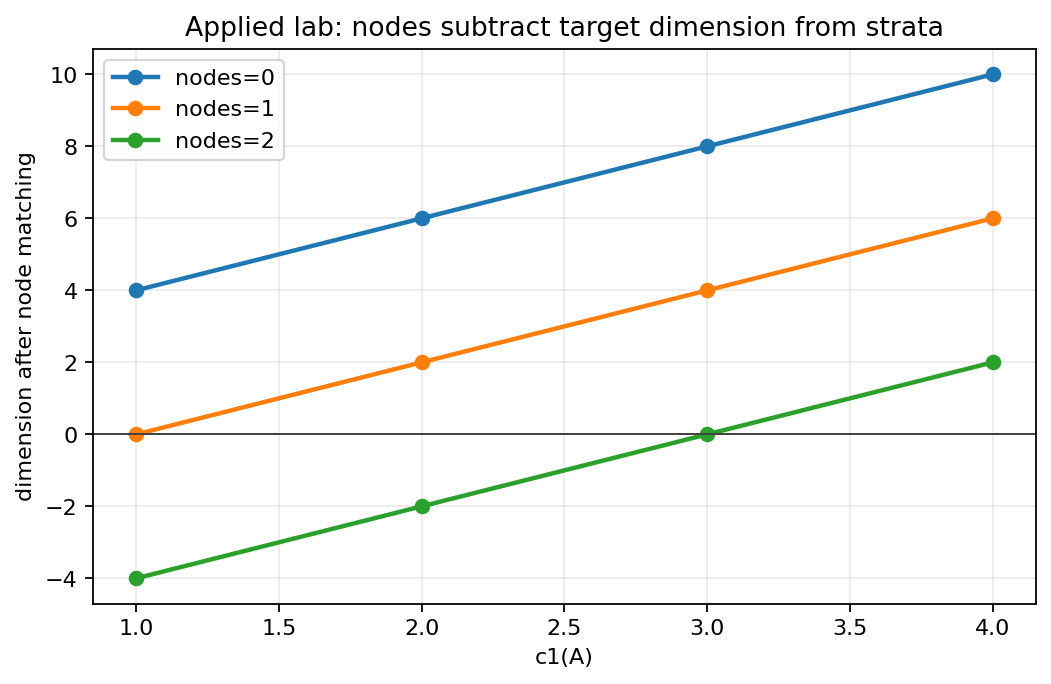

In [7]:
lab_rows = []
target_n = 2
for c1_value in [1, 2, 3, 4]:
    for marks in [0, 1, 2, 3]:
        base_dim = int(component_dim.subs({n_sym: target_n, c_sym: c1_value, k_sym: marks}))
        for nodes in [0, 1, 2]:
            dim_after_nodes = base_dim - int(node_subtraction.subs({n_sym: target_n, e_sym: nodes}))
            codim = base_dim - dim_after_nodes
            lab_rows.append({"target_complex_dim": target_n, "c1": c1_value, "marks": marks, "nodes": nodes, "base_dim": base_dim, "dim_after_nodes": dim_after_nodes, "node_codim": codim, "pseudocycle_safe_boundary": bool(nodes == 0 or codim >= 2)})
lab = pd.DataFrame(lab_rows)
lab.to_csv(TABLE_DIR / "evaluation-constraint-lab.csv", index=False)
fig, ax = plt.subplots(figsize=(7.6, 4.5))
for nodes, group in lab[(lab["marks"] == 2)].groupby("nodes"):
    ax.plot(group["c1"], group["dim_after_nodes"], marker="o", lw=2, label=f"nodes={nodes}")
ax.axhline(0, color="#444", lw=0.9)
ax.set_xlabel("c1(A)")
ax.set_ylabel("dimension after node matching")
ax.set_title("Applied lab: nodes subtract target dimension from strata")
ax.legend()
ax.grid(alpha=0.25)
fig_path = save_matplotlib(fig, UNIT, "figures", "evaluation-constraint-lab.png")
plt.close(fig)
lab_checks = {"rows": int(len(lab)), "all_node_boundaries_safe": bool(lab[lab["nodes"] > 0]["pseudocycle_safe_boundary"].all()), "node_subtraction_for_one_edge": int(lab[(lab.c1 == 3) & (lab.marks == 2) & (lab.nodes == 1)].node_codim.iloc[0]), "has_zero_node_main_rows": bool((lab["nodes"] == 0).any()), "passed": True}
lab_checks["passed"] = lab_checks["all_node_boundaries_safe"] and lab_checks["node_subtraction_for_one_edge"] == 4
save_json(lab_checks, UNIT, "checks", "evaluation-constraint-lab-checks.json")
display_artifact(fig_path, width=760)


## Takeaways

- Chapter 6 turns compactified stable maps into countable objects by controlling transversality and boundary codimension.
- Edge-evaluation transversality is the local mechanism behind node matching: the diagonal condition subtracts the target dimension cleanly.
- Semipositivity is a dimension-safety hypothesis. It excludes bubble behavior that could create codimension-one boundary in the evaluation image.
- A pseudocycle can have an omega-limit set, but that limiting set must have codimension at least two to preserve intersection counts.
- Graph pseudocycles combine several components, nodes, and marked constraints; the same dimension bookkeeping is applied edge by edge.


## Final Sanity Checks

The final cell verifies source coverage, library routing, visual storyboard, stratum and semipositivity ledgers, edge-evaluation transversality, pseudocycle proof graph, graph-pseudocycle incidence diagram, symbolic dimension formulas, and the applied lab. It reloads the JSON checks to ensure unsafe rows are flagged, the edge-evaluation Jacobian has full rank, proof paths reach both GW and graph pseudocycles, and node matching subtracts the expected target dimension.


In [8]:
expected_artifacts = [
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "library-routing.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "pseudocycle-codimension-checks.json",
    CHECK_DIR / "edge-evaluation-transversality-checks.json",
    CHECK_DIR / "pseudocycle-proof-pipeline-checks.json",
    CHECK_DIR / "dimension-formula-checks.json",
    CHECK_DIR / "evaluation-constraint-lab-checks.json",
    FIG_DIR / "stable-map-stratum-codimension.png",
    FIG_DIR / "semipositivity-bubble-ledger.png",
    FIG_DIR / "edge-evaluation-diagonal-transversality.png",
    FIG_DIR / "pseudocycle-proof-pipeline.png",
    FIG_DIR / "graph-pseudocycle-incidence.png",
    FIG_DIR / "evaluation-constraint-lab.png",
    TABLE_DIR / "stable-map-stratum-codimension.csv",
    TABLE_DIR / "semipositivity-bubble-ledger.csv",
    TABLE_DIR / "evaluation-constraint-lab.csv",
]
for artifact in expected_artifacts:
    assert_artifact(artifact)
assert_artifact(CHECK_DIR / "source-coverage.json")
assert_artifact(CHECK_DIR / "visual-storyboard.json")
assert_artifact(FIG_DIR / "stable-map-stratum-codimension.png")
assert_artifact(FIG_DIR / "pseudocycle-proof-pipeline.png")

check_names = ["pseudocycle-codimension-checks.json", "edge-evaluation-transversality-checks.json", "pseudocycle-proof-pipeline-checks.json", "dimension-formula-checks.json", "evaluation-constraint-lab-checks.json"]
checks = [json.loads((CHECK_DIR / name).read_text(encoding="utf-8")) for name in check_names]
final_sanity = {
    "artifact_count": len(expected_artifacts),
    "all_json_checks_passed": all(item.get("passed", False) for item in checks),
    "safe_boundaries_codim_two": checks[0]["all_safe_boundaries_codim_at_least_two"],
    "edge_eval_full_rank": checks[1]["full_rank"],
    "proof_reaches_graph_pseudocycle": checks[2]["reaches_graph_pseudocycle"],
    "dimension_formula_checked": checks[3]["passed"],
    "lab_node_subtraction_checked": checks[4]["node_subtraction_for_one_edge"] == 4,
    "passed": True,
}
final_sanity["passed"] = all(value for key, value in final_sanity.items() if key != "artifact_count")
save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(CHECK_DIR / "final-sanity.json")
final_sanity


{'artifact_count': 17,
 'all_json_checks_passed': True,
 'safe_boundaries_codim_two': True,
 'edge_eval_full_rank': True,
 'proof_reaches_graph_pseudocycle': True,
 'dimension_formula_checked': True,
 'lab_node_subtraction_checked': True,
 'passed': True}